In [41]:
from quark import Task
token = 'Please Insert your token here (SQC Lab - Quafu)'
tmgr = Task(token)
tmgr.status()

{'Baihua': 34,
 'Yudu': 'Calibrating',
 'Dongling': 5,
 'Haituo': 'Calibrating',
 'Baiwang': 15,
 'Fenghuang': 1,
 'Haituo-2': 'Maintenance',
 'Hongluo': 'Calibrating',
 'Jiu': 'Maintenance',
 'Ling': 'Maintenance',
 'Lingkai-1': 'Calibrating',
 'Lingkai-2': 'Calibrating',
 'Miaofeng': 'Maintenance',
 'Shenglian': 'Calibrating',
 'Xiang': 'Maintenance'}

In [42]:
import numpy as np
import matplotlib.pyplot as plt
from qiskit import QuantumCircuit
from qiskit_aer import AerSimulator
from qiskit.quantum_info import Operator
from qiskit.visualization import plot_histogram

     ┌───┐┌───┐ ░ ┌───────┐ ░              
q_0: ┤ H ├┤ Z ├─░─┤1      ├─░──────────────
     ├───┤├───┤ ░ │  P_op │ ░ ┌───┐┌───┐┌─┐
q_1: ┤ H ├┤ S ├─░─┤0      ├─░─┤ S ├┤ H ├┤M├
     └───┘└───┘ ░ └───────┘ ░ └───┘└───┘└╥┘
c: 1/════════════════════════════════════╩═
                                         0 
Simulation Results: {'1': 8192}


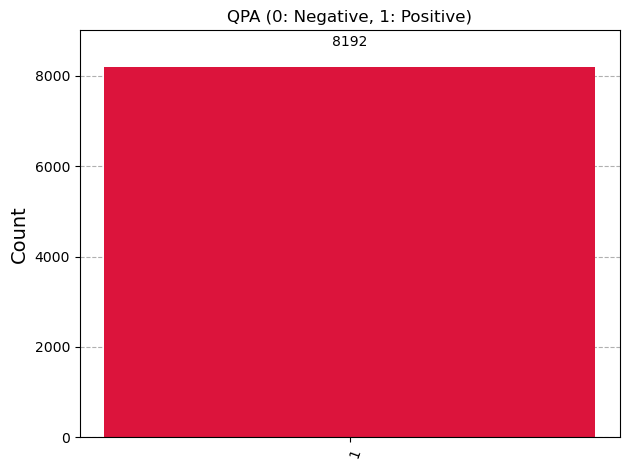

In [43]:
# 1. Circuit Setup (2 Qubits, 1 Classical Bit)
qc = QuantumCircuit(2, 1)

# Article: q0 -> H, Z | q1 -> H, S
qc.h(0)
qc.z(0)
qc.h(1)
qc.s(1)
qc.barrier()

# 2. Permutation Operator

#P0+ IDENTITY
U = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]], dtype=complex)

perm_op = Operator(U)
qc.unitary(perm_op, [1, 0], label='P_op')
qc.barrier()

# 3. Analysis and Measurement
qc.s(1)
qc.h(1)
qc.measure(1, 0)

# Visualization 1: Circuit Diagram
print(qc.draw())

# Simulation
simulator = AerSimulator()
job = simulator.run(qc, shots=8192)
result = job.result()
counts = result.get_counts()

# Visualization 2: Simulation Results
print(f"Simulation Results: {counts}")
plot_histogram(counts, title="QPA (0: Negative, 1: Positive)", color='crimson')

In [44]:
from qiskit import qasm2, transpile

# 1. Convert to basic gates that Quafu can understand (Transpile)
# Quafu does not recognize special matrices, so convert them to standard gates (u, cx, id).
basis_gates = ['u', 'cx', 'id']
qc_decomposed = transpile(qc, basis_gates=basis_gates, optimization_level=1)

#2. Export in OpenQASM 2.0 format
qasm = qasm2.dumps(qc_decomposed)

print(qasm)

OPENQASM 2.0;
include "qelib1.inc";
qreg q[2];
creg c[1];
u(pi/2,-pi,-pi) q[0];
u(pi/2,pi/2,-pi) q[1];
barrier q[0],q[1];
barrier q[0],q[1];
u(pi/2,0,-pi/2) q[1];
measure q[1] -> c[0];


In [50]:
# Preparing the task
task = {'chip': 'Baihua',  # chip name
        'name': 'QPA',  # task name
        'circuit':qasm, # qasm
        'compile':True
        }

In [51]:
# Sending our task to Quafu's quantum computer
tid = tmgr.run(task)

In [57]:
# Task status
tmgr.status(tid)

'Finished'

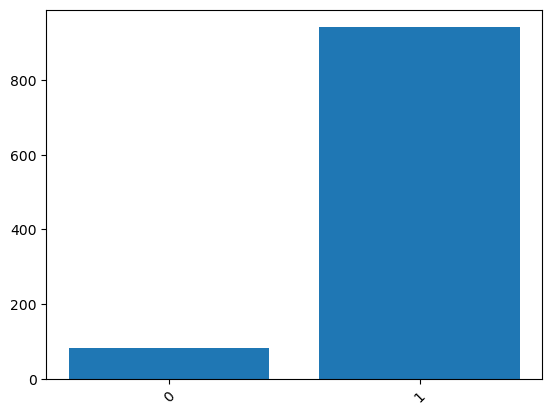

In [58]:
# Graph: The results from quantum computer
res = tmgr.result(tid)
data = res['count']
bases = sorted(data)
count = [data[base] for base in bases]

plt.bar(bases, count)
ticks = plt.xticks(rotation=45)

In [ ]:
Operator	THE GATES
P0+​	    (Empty Circuit) (I)
P1+​	    CNOT(q1​,q0​), then X(q1​)
P2+​	    X(q0​)
P3+​	    CNOT(q1​,q0​), then X(q1​),X(q0​)    
P0−​	    CNOT(q1​,q0​)
P1−​	    X(q1​)
P2−​	    CNOT(q1​,q0​), then X(q0​)
P3−​	    X(q1​),X(q0​)

In [ ]:
"""

#P0+ IDENTITY
U = np.array([
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1]], dtype=complex)

---------------------------------

#P1+
U = np.array([
    [0, 0, 0, 1],
    [1, 0, 0, 0],
    [0, 1, 0, 0],
    [0, 0, 1, 0]], dtype=complex)

---------------------------------

#P2+
U = np.array([
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 0, 0],
    [0, 1, 0, 0]], dtype=complex)

---------------------------------

#P3+
U = np.array([
    [0, 1, 0, 0],
    [0, 0, 1, 0],
    [0, 0, 0, 1],
    [1, 0, 0, 0]], dtype=complex)

---------------------------------

#P0-
U = np.array([
    [1, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0],
    [0, 1, 0, 0]], dtype=complex)

---------------------------------

#P1-
U = np.array([
    [0, 1, 0, 0],
    [1, 0, 0, 0],
    [0, 0, 0, 1],
    [0, 0, 1, 0]], dtype=complex)

---------------------------------

#P2-
U = np.array([
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [1, 0, 0, 0],
    [0, 0, 0, 1]], dtype=complex)

---------------------------------

#P3-
U = np.array([
    [0, 0, 0, 1],
    [0, 0, 1, 0],
    [0, 1, 0, 0],
    [1, 0, 0, 0]], dtype=complex)

"""